# 02_Myeloid_Refinement
## Xiaonan Wang
## 16Sep2026

In [1]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [21]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [2]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"5/64 logical CPU cores, x86_64"
GPU,No GPU found


In [3]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakaraov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

## Step0 - Read in Files

In [4]:
x_myeloid = sc.read_h5ad(datadir + "myeloid_xenium.h5ad")

## Step1 - Refine Myeloid Cell Types By Leiden Clustering

running Leiden clustering


/tmp/ipykernel_2630288/377621021.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(x_myeloid, resolution=2, key_added='Leiden_myeloid')


    finished: found 16 clusters and added
    'Leiden_myeloid', the cluster labels (adata.obs, categorical) (0:00:22)


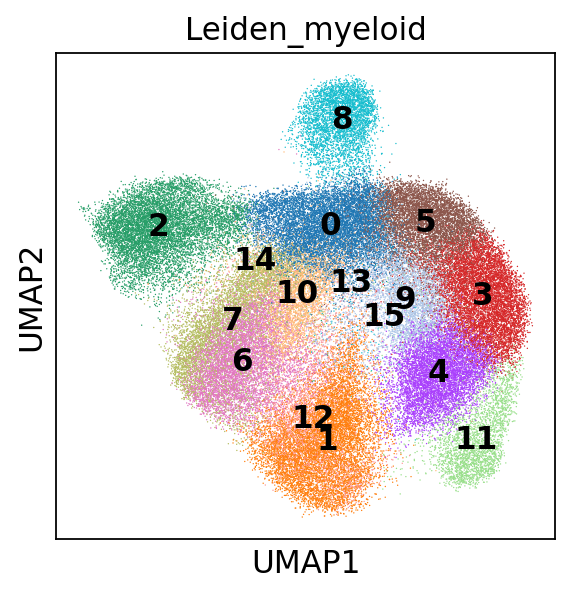

In [5]:
sc.tl.leiden(x_myeloid, resolution=2, key_added='Leiden_myeloid')
sc.pl.umap(x_myeloid, color='Leiden_myeloid', legend_loc='on data')

In [6]:
sc.tl.rank_genes_groups(x_myeloid, groupby='Leiden_myeloid', n_genes=x_myeloid.shape[1], method='wilcoxon', key_added='DE_Leiden_myeloid')

ranking genes
    finished: added to `.uns['DE_Leiden_myeloid']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:03)


In [7]:
pd.DataFrame(x_myeloid.uns['DE_Leiden_myeloid']['names']).head(50)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,SPP1,LILRB2,MARCO,SELL,SELL,CXCL8,MMP2,CD163,KIT,FCN3,GPR183,HMGB2,CD300E,CD300E,KRT8,CDKN1A
1,MARCO,CD300E,CD68,S100A12,S100A12,PI3,CD163,MS4A4A,IL1RL1,SERPINE1,CD74,MAPK14,ANPEP,LILRB2,CEACAM6,ICAM1
2,APOE,AIF1,VSIG4,MAPK14,MAPK14,CXCR4,FN1,GPR183,SLC18A2,CXCR2,AREG,CEACAM6,CD14,FCGR3A,CD74,DNAJB1
3,CHIT1,PECAM1,APOE,CXCR2,FCN3,AQP9,CD74,CD74,AREG,S100A12,HLA-DQB1,CD24,LILRB2,PECAM1,CCL2,FOS
4,WIF1,MPEG1,CD74,VSIR,HMGB2,PLAU,GPR183,VSIG4,PTGS1,IL1RL1,VEGFA,GPI,CD44,MAPK1,CXCL8,CXCR4
5,ELF3,VSIR,ANXA1,HMGB2,VSIR,CCL3,IGFBP7,CTSL,MS4A2,PECAM1,CDKN1A,ANXA1,AIF1,WIF1,KRT7,PECAM1
6,IFNG,CD14,CD44,AQP9,CXCR2,CCL4,MS4A4A,CD68,HPGDS,CDH5,ADAM28,RETN,HIF1A,FABP3,HSPA8,AIF1
7,SFTPD,ITGAL,CTSL,CXCR4,PECAM1,IL1B,HLA-DQB1,FPR3,FN1,VWF,CD80,CLEC12A,AQP9,CASP1,SERPINE1,SELL
8,ARL14,TYROBP,ANPEP,CLEC4E,FLT1,CLEC4E,LTBP2,HLA-DQB1,MMP2,FLT1,CXCL2,APP,FCN1,CD27,TRAM1,ATM
9,KRT17,FCN1,CD47,MMP9,HLA-E,VEGFA,CTSL,SLC1A3,VEGFA,SELL,IGFBP7,LTF,TYROBP,TNFRSF17,CD47,FCGR3A


In [8]:
celltype_order = [
    # Macrophages
    "AM",
    "AM-like",
    "LYVE1+ IM",
    "MMP2+ IM",

    # Monocytes
    "CD14+ Mono",
    "FCGR3A+ Mono",

    # Dendritic cells
    "DC",

    # Neutrophils
    "CXCR2+ Neu",
    "Vascular Neu",
    "CXCL8+ Neu",

    # Other immune/myeloid states
    "Cycling Myeloid",
    "MC",
    "Mixed"
]

In [9]:
cluster_to_celltype = {
    "2":  "AM",                 # Alveolar Macrophage
    "0":  "AM-like",            # SPP1+ Macrophage
    "7":  "LYVE1+ IM",          # LYVE1+ Interstitial Macrophage
    "6":  "MMP2+ IM",           # MMP2+ Interstitial Macrophage
    "12": "CD14+ Mono",         # CD14+ Monocyte
    "1":  "FCGR3A+ Mono",       # FCGR3A+ Monocyte/Mo-Mac
    "10": "DC",                 # CD1C+ cDC2
    "15": "DC",                 # FSCN1+ Activated DC/Mo-DC
    "3":  "CXCR2+ Neu",         # CXCR2+ Neutrophil
    "4":  "Vascular Neu",       # Vascular-associated Neutrophil
    "5":  "CXCL8+ Neu",         # CXCL8+ Activated Neutrophil
    "11": "Cycling Myeloid",    # Cycling Myeloid
    "8":  "MC",                 # Mast Cell
    "13": "Mixed",             # Activated Lymphocyte
    "9":  "Mixed",        # Vascular Endothelial
    "14": "Mixed",                # AT1
}

In [12]:
x_myeloid.obs["Leiden_myeloid"].value_counts()

Leiden_myeloid
0     9105
1     8721
2     8711
3     7854
4     6989
5     6795
6     6662
7     5673
8     4155
9     4056
10    3718
11    2913
12    2840
13     309
14      19
15       6
Name: count, dtype: int64

In [10]:
x_myeloid.obs["CellType"] = pd.Categorical([cluster_to_celltype[x] for x in x_myeloid.obs["Leiden_myeloid"]],     
                                           categories=celltype_order,
                                           ordered=True)

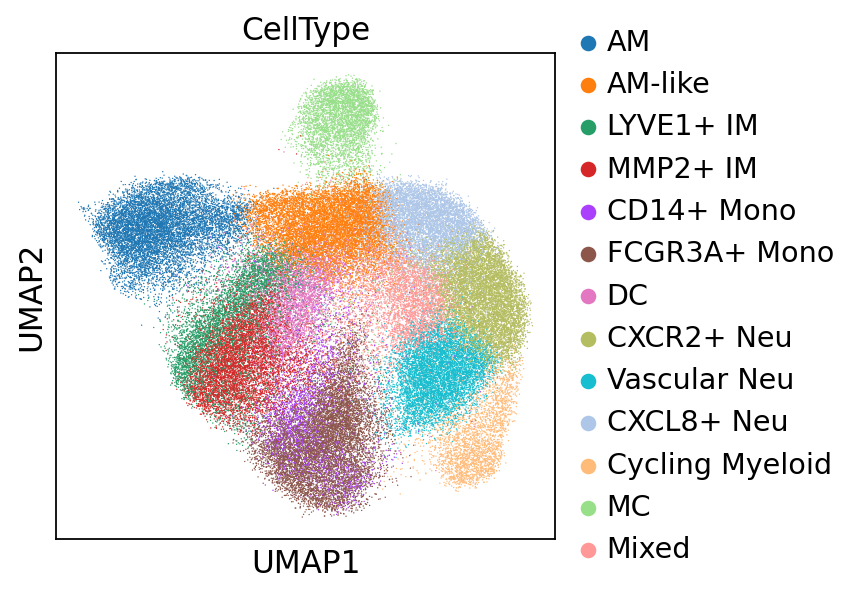

In [11]:
sc.pl.umap(x_myeloid, color='CellType')

In [14]:
celltype_markers = {
    "AM-like": [
        "SPP1", "CHIT1", "WIF1"
    ],
    "FCGR3A+ Mono": [
        "FCGR3A", "LILRA5", "ITGAM"
    ],
    "AM": [
        "MARCO", "CD68", "APOE"
    ],
    "CXCR2+ Neu": [
        "CXCR2", "S100A12", "CLEC4E"
    ],
    "Vascular Neu": [
        "SELL", "FCN3", "FLT1"
    ],
    "CXCL8+ Neu": [
        "CXCL8", "PI3", "CCL3"
    ],
    "MMP2+ IM": [
        "MMP2", "IGFBP7", "CXCL12"
    ],
    "LYVE1+ IM": [
        "LYVE1", "MS4A4A", "VSIG4"
    ],
    "MC": [
        "KIT", "MS4A2", "HPGDS"
    ],
    "Endothelial": [
        "PECAM1", "CDH5", "VWF"
    ],
    "DC": [
        "CD1C", "CLEC10A", "HLA-DQB1"
    ],
    "Cycling Myeloid": [
        "MKI67", "TOP2A", "CDK1"
    ],
    "CD14+ Mono": [
        "CD14", "FCN1", "CD300E"
    ],
    "Lympho": [
        "CD3D", "NKG7", "GZMB"
    ],
    "AT1": [
        "AGER", "PDPN", "EMP2"
    ]
}

In [17]:
available_markers = {
    celltype: [
        gene for gene in genes
        if gene in x_myeloid.var_names
    ]
    for celltype, genes in celltype_markers.items()
}

missing_markers = {
    celltype: [
        gene for gene in genes
        if gene not in x_myeloid.var_names
    ]
    for celltype, genes in celltype_markers.items()
}

print("Available markers:")
for celltype, genes in available_markers.items():
    print(f"{celltype}: {genes}")

print("\nMissing markers:")
for celltype, genes in missing_markers.items():
    if genes:
        print(f"{celltype}: {genes}")

Available markers:
AM-like: ['SPP1', 'CHIT1', 'WIF1']
FCGR3A+ Mono: ['FCGR3A', 'LILRA5', 'ITGAM']
AM: ['MARCO', 'CD68', 'APOE']
CXCR2+ Neu: ['CXCR2', 'S100A12', 'CLEC4E']
Vascular Neu: ['SELL', 'FCN3', 'FLT1']
CXCL8+ Neu: ['CXCL8', 'PI3', 'CCL3']
MMP2+ IM: ['MMP2', 'IGFBP7', 'CXCL12']
LYVE1+ IM: ['LYVE1', 'MS4A4A', 'VSIG4']
MC: ['KIT', 'MS4A2', 'HPGDS']
Endothelial: ['PECAM1', 'CDH5', 'VWF']
DC: ['CD1C', 'CLEC10A', 'HLA-DQB1']
Cycling Myeloid: ['MKI67', 'TOP2A', 'CDK1']
CD14+ Mono: ['CD14', 'FCN1', 'CD300E']
Lympho: ['CD3D', 'NKG7', 'GZMB']
AT1: ['AGER', 'PDPN', 'EMP2']

Missing markers:


In [18]:
ordered_markers = {
    celltype: available_markers[celltype]
    for celltype in celltype_order
    if celltype in available_markers
}

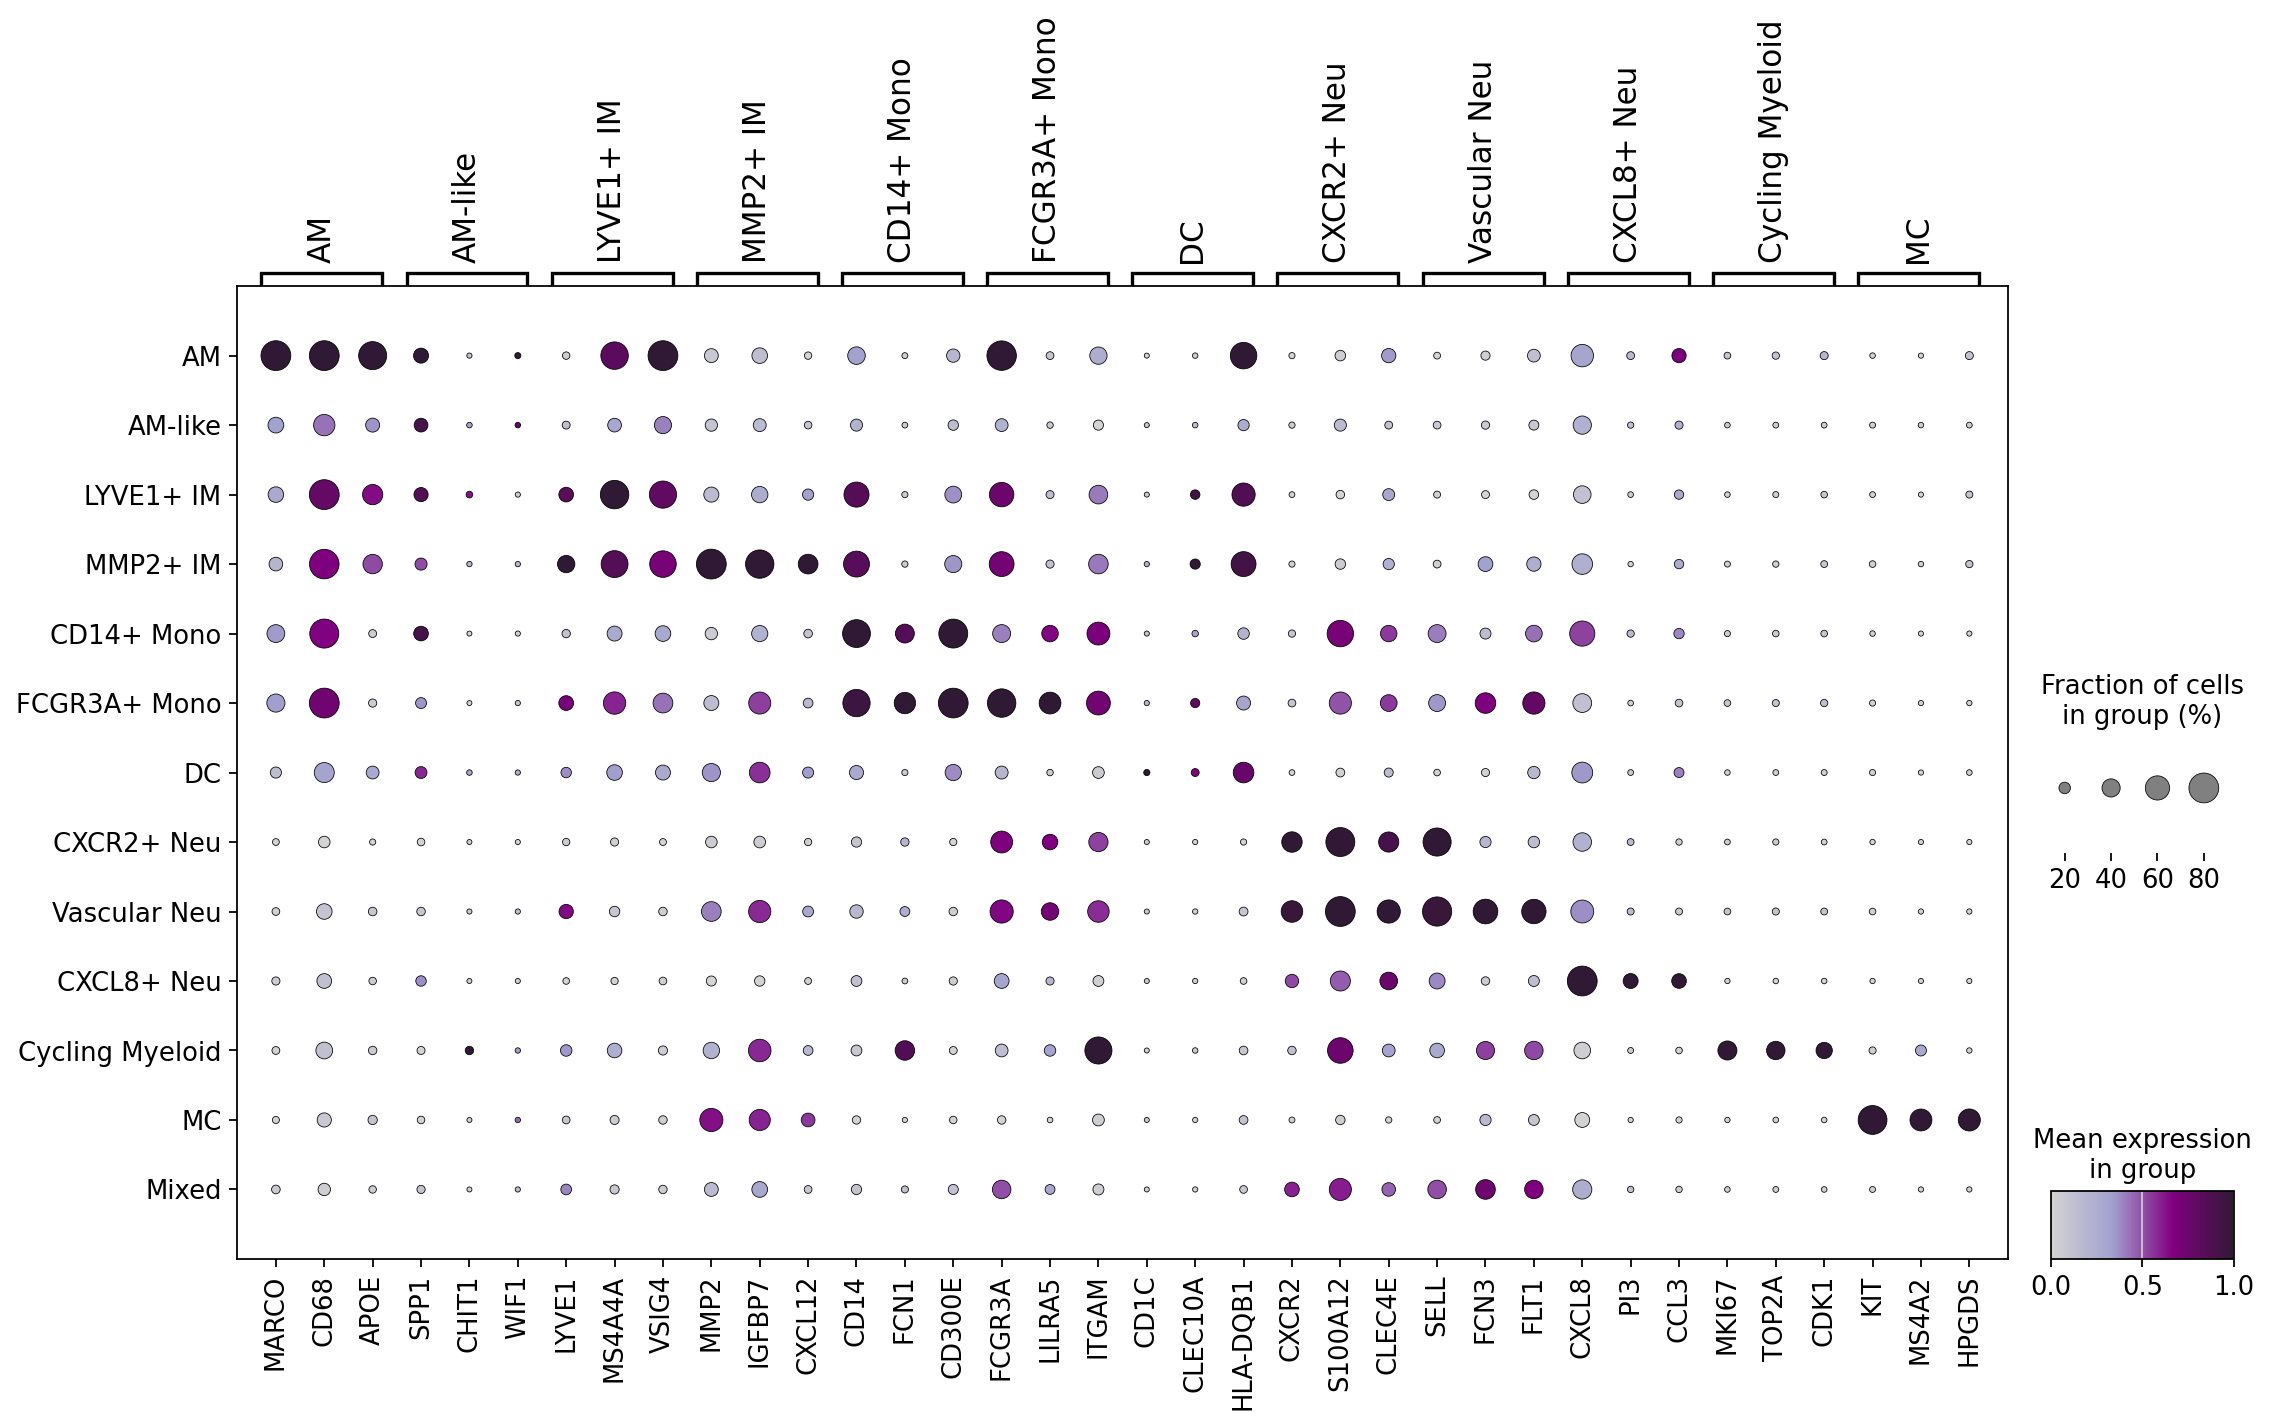

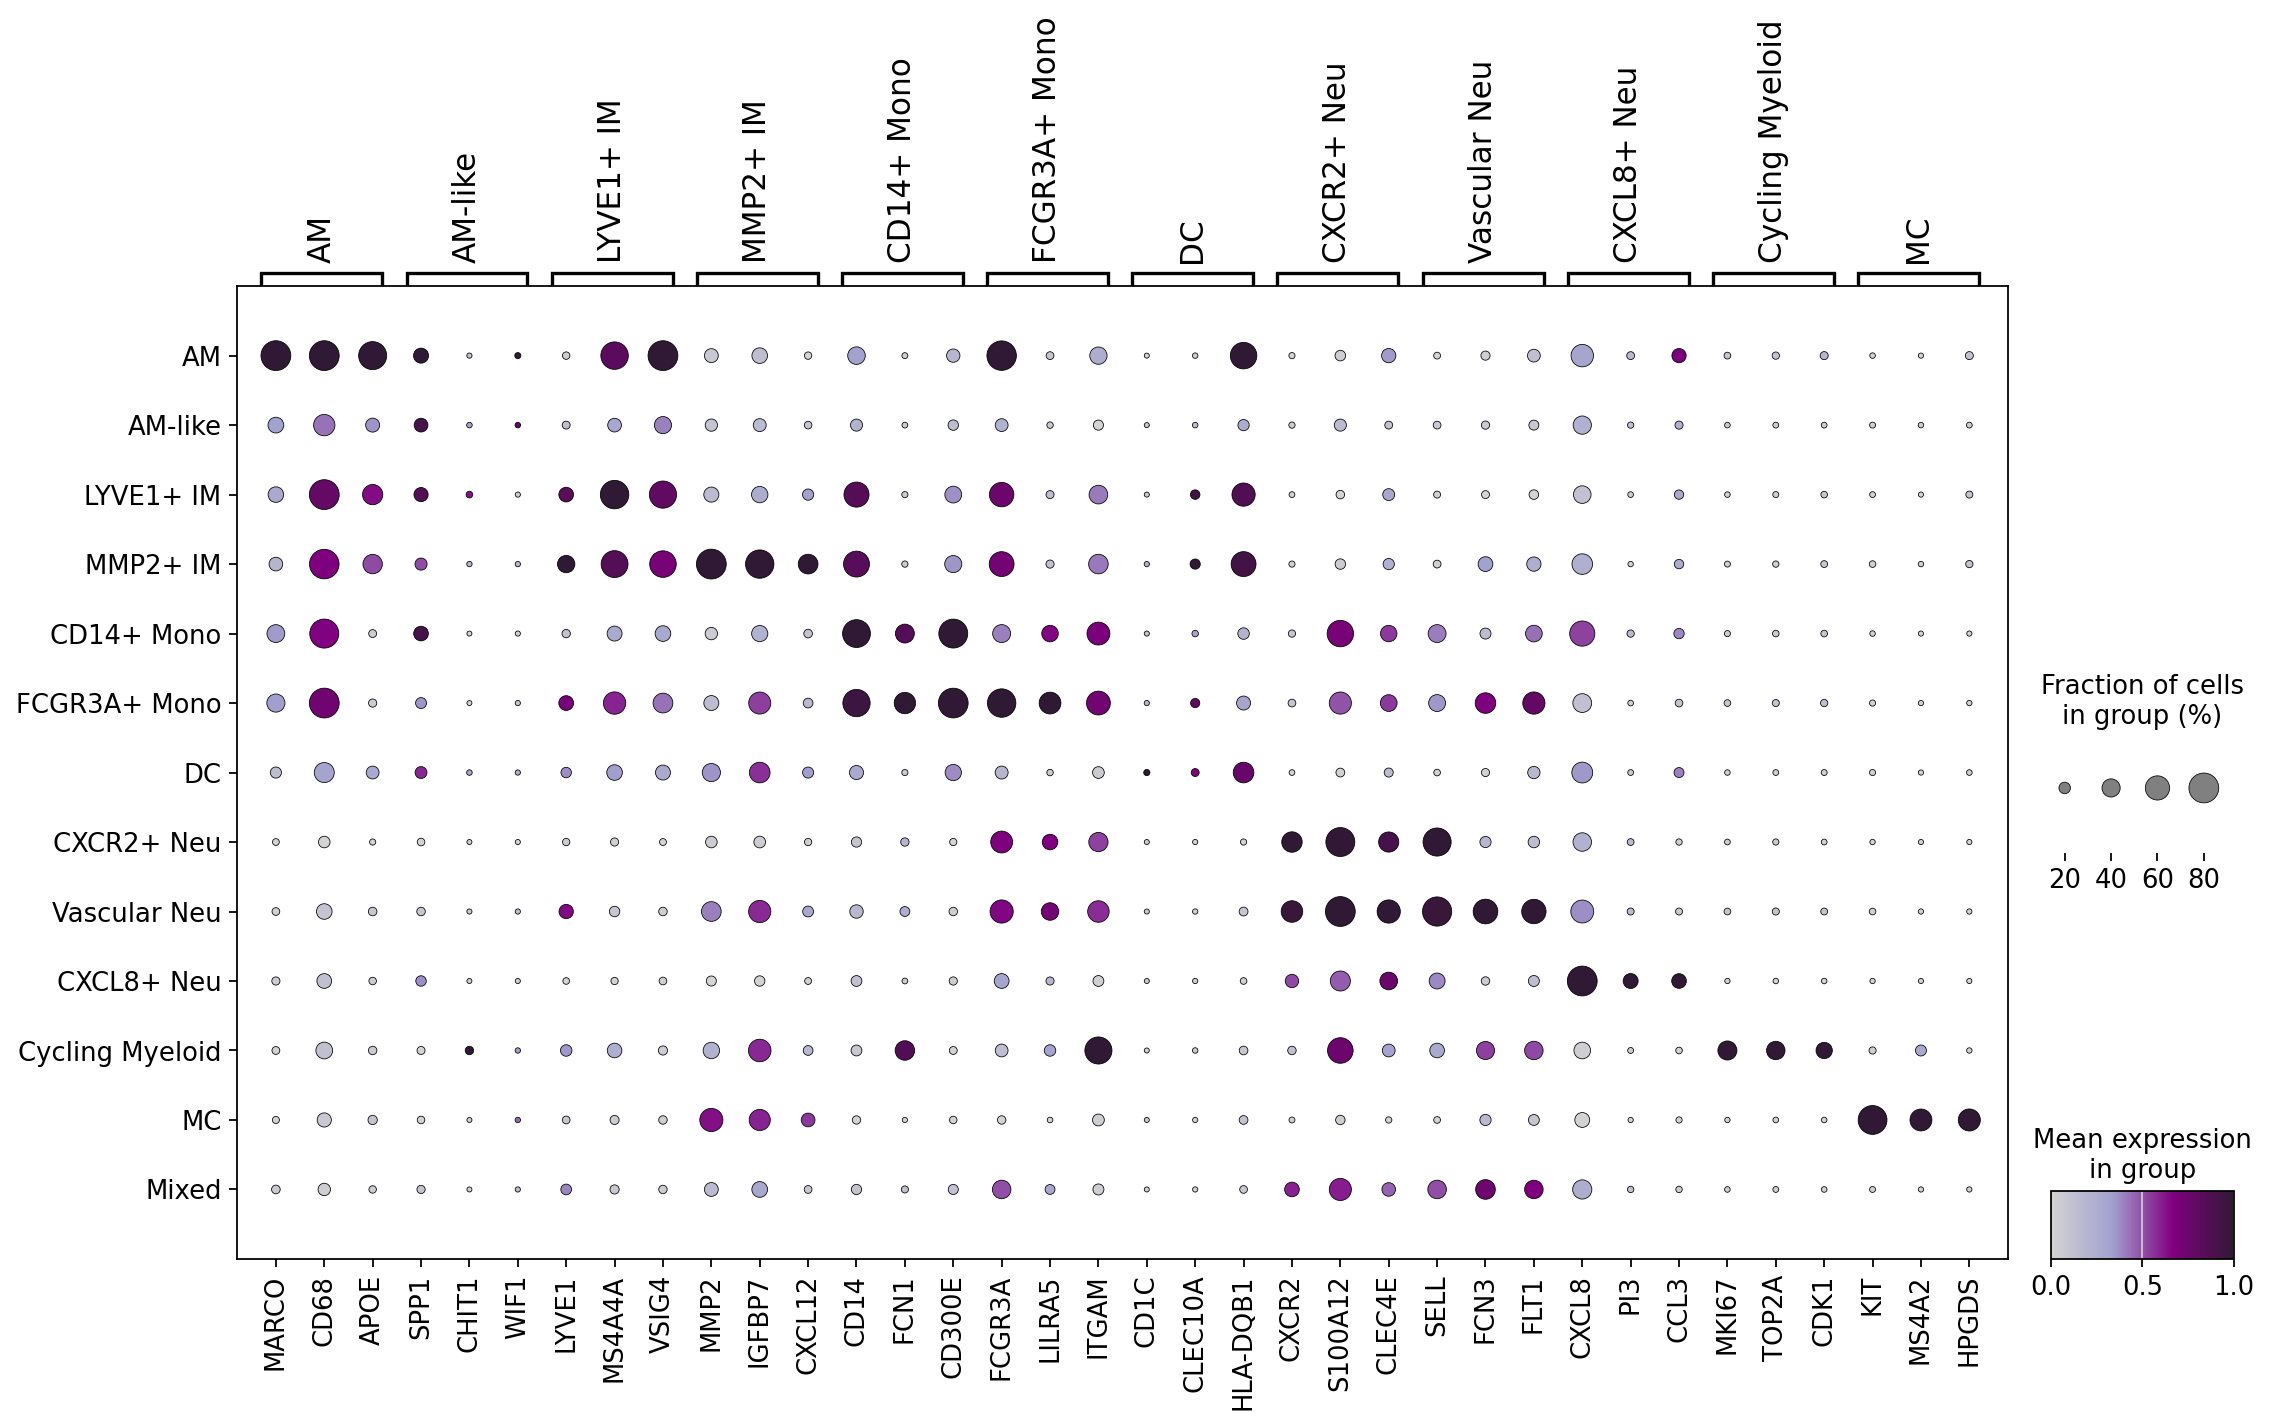

In [19]:
dotplot = sc.pl.dotplot(
    x_myeloid,
    var_names=ordered_markers,
    groupby="CellType",
    categories_order=celltype_order,
    use_raw=False,
    standard_scale="var",
    cmap=cmap,
    dot_min=0,
    dot_max=0.8,
    smallest_dot=5,
    figsize=(16, 8),
    return_fig=True,
    show=False,
)

dotplot.style(
    dot_edge_color="black",
    dot_edge_lw=0.35,
    largest_dot=180,
)

dotplot.make_figure()
dotplot.savefig(
    "Xenium_myeloid_celltype_annotation_dotplot.pdf"
)

In [22]:
from scipy import sparse
genes_check = ["SPP1", "MARCO", "APOE", "CHIT1"]

spp1_check = source.cluster_expression_summary(
    adata=x_myeloid,
    genes=genes_check,
    groupby="CellType",
)

display(
    spp1_check[
        spp1_check["CellType"].isin([
            "AM",
            "AM-like",
            "LYVE1+ IM",
            "MMP2+ IM",
        ])
    ].sort_values(["gene", "pct_expressing"], ascending=[True, False])
)

,CellType,gene,mean_expression,pct_expressing,n_cells
2,AM,APOE,4.036555,73.493284,8711
34,LYVE1+ IM,APOE,2.682658,46.641988,5673
42,MMP2+ IM,APOE,2.185728,43.980787,6662
6,AM-like,APOE,1.619544,27.204833,9105
35,LYVE1+ IM,CHIT1,0.324798,6.416358,5673
7,AM-like,CHIT1,0.165815,3.031301,9105
43,MMP2+ IM,CHIT1,0.111544,2.386671,6662
3,AM,CHIT1,0.075215,1.767880,8711
1,AM,MARCO,4.985813,90.207783,8711
5,AM-like,MARCO,1.887399,32.597474,9105


## Step2 - Check %Macro Subtypes Within All Macrophage Per Core in Each Tissue

In [23]:
core_cols = ["donor_id", "tma_id", "core_id"]
macrophage_types = [
    "AM",
    "AM-like",
    "LYVE1+ IM",
    "MMP2+ IM",
]
obs = x_myeloid.obs.copy()

# Ensure missing annotations are retained
obs["tissue_annotation"] = (
    obs["tissue_annotation"]
    .astype("object")
    .fillna("None")
)

core_annotation = (
    obs[core_cols + ["tissue_annotation"]]
    .drop_duplicates()
)

mac_obs = obs[
    obs["CellType"].isin(macrophage_types)
].copy()

macrophage_pct_long = (
    mac_obs
    .groupby(core_cols, observed=True)["CellType"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent_within_macrophages")
    .reset_index()
)

macrophage_pct_long["percent_within_macrophages"] = (
    macrophage_pct_long["percent_within_macrophages"].round(2)
)

macrophage_pct_long = macrophage_pct_long.merge(
    core_annotation,
    on=core_cols,
    how="left",
)

macrophage_pct_long = macrophage_pct_long[
    core_cols
    + ["tissue_annotation", "CellType", "percent_within_macrophages"]
]

macrophage_pct_long = (
    macrophage_pct_long[
        macrophage_pct_long["CellType"].isin(macrophage_types)
    ]
    .copy()
    .reset_index(drop=True)
)

# Preserve the biological plotting order
macrophage_pct_long["CellType"] = pd.Categorical(
    macrophage_pct_long["CellType"],
    categories=macrophage_types,
    ordered=True,
)

display(macrophage_pct_long.head())

,donor_id,tma_id,core_id,tissue_annotation,CellType,percent_within_macrophages
0,D1,TMA1,D1.c1,A,AM-like,31.82
1,D1,TMA1,D1.c1,A,MMP2+ IM,29.26
2,D1,TMA1,D1.c1,A,AM,20.17
3,D1,TMA1,D1.c1,A,LYVE1+ IM,18.75
4,D1,TMA1,D1.c2,A,MMP2+ IM,35.28


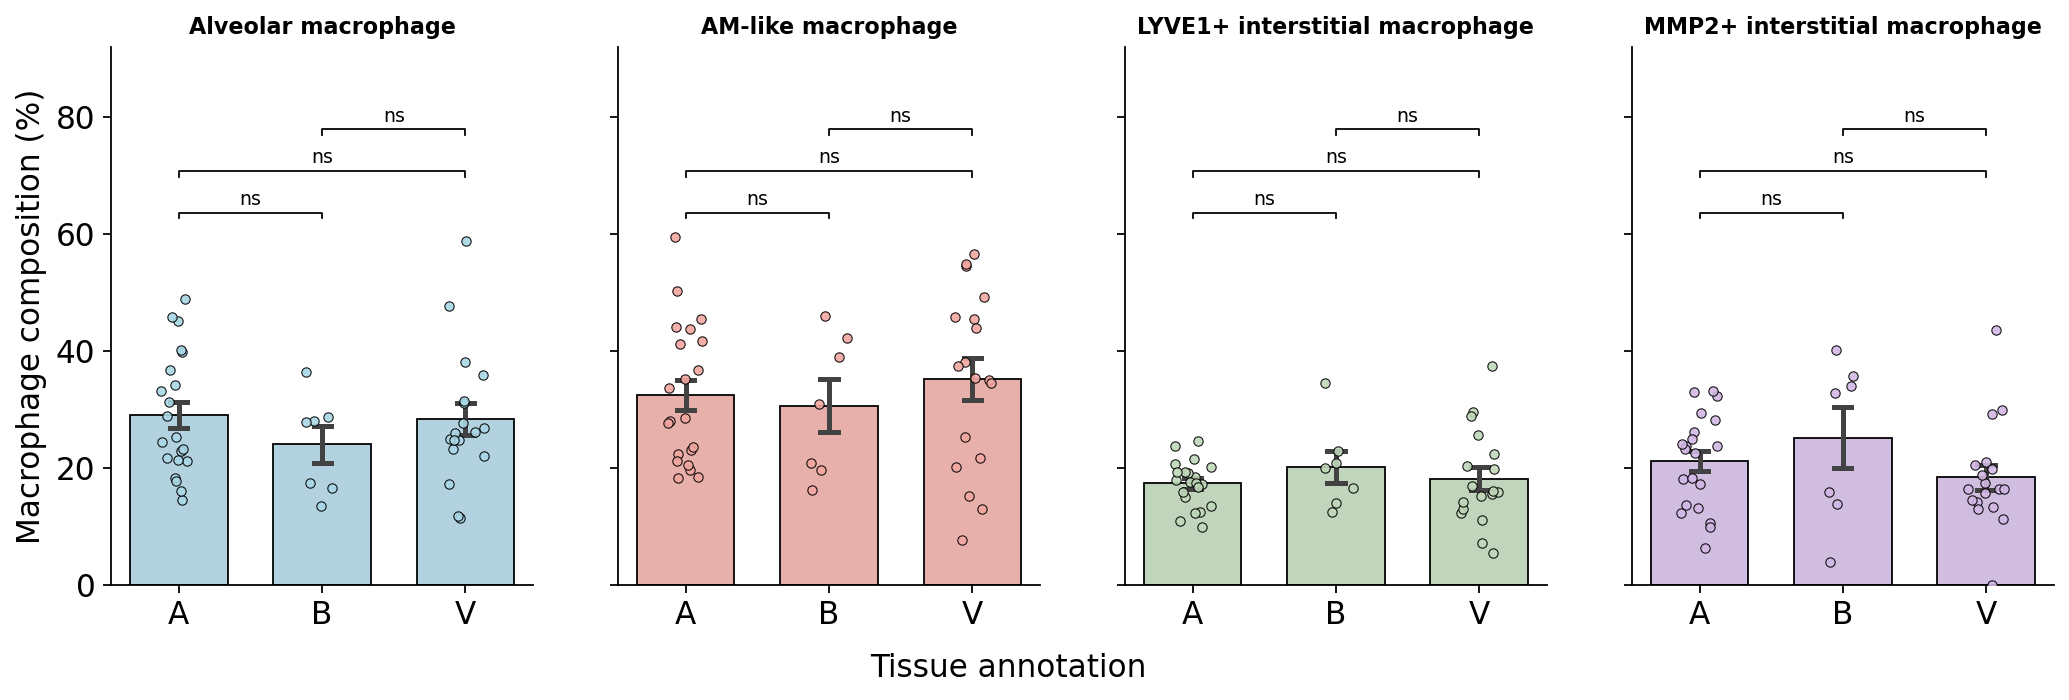

In [25]:
fig, axes, macrophage_donor_summary, macrophage_stats = (
    source.plot_macrophage_pct_by_tissue(
        macrophage_pct_long,
        tissue_order=("A", "B", "V"),
        comparisons=(
            ("A", "B"),
            ("A", "V"),
            ("B", "V"),
        ),
        value_col="percent_within_macrophages",
        ylabel="Macrophage composition (%)",
        show_ns=True,
        save="Macrophage_composition_by_tissue.pdf",
    )
)

In [26]:
display(
    macrophage_stats[
        [
            "CellType",
            "tissue1",
            "tissue2",
            "n_paired_donors",
            "p_value",
            "p_adj",
            "significance",
        ]
    ].round({
        "p_value": 4,
        "p_adj": 4,
    })
)

,CellType,tissue1,tissue2,n_paired_donors,p_value,p_adj,significance
0,AM,A,B,6,0.4375,0.8438,ns
1,AM,A,V,17,0.5477,0.8438,ns
2,AM,B,V,7,0.3750,0.8438,ns
3,AM-like,A,B,6,0.8438,1.0000,ns
4,AM-like,A,V,17,0.1901,0.8438,ns
5,AM-like,B,V,7,0.9375,1.0000,ns
6,LYVE1+ IM,A,B,6,0.5625,0.8438,ns
7,LYVE1+ IM,A,V,17,0.7819,1.0000,ns
8,LYVE1+ IM,B,V,7,1.0000,1.0000,ns
9,MMP2+ IM,A,B,6,0.5625,0.8438,ns


## Step3 - Check %Macro Subtypes Within Each Core in Each Tissue

In [29]:
x_all = sc.read_h5ad(datadir + "xenium.h5ad")

In [27]:
core_cols = ["donor_id", "tma_id", "core_id"]

macrophage_order = [
    "AM",
    "AM-like",
    "LYVE1+ IM",
    "MMP2+ IM",
]

In [30]:
all_core_summary = (
    x_all.obs
    .assign(
        tissue_annotation=lambda d:
            d["tissue_annotation"]
            .astype("object")
            .fillna("None")
            .astype(str)
    )
    .groupby(
        core_cols + ["tissue_annotation"],
        observed=True,
    )
    .size()
    .rename("n_all_cells")
    .reset_index()
)

In [31]:
myeloid_obs = x_myeloid.obs.copy()

short_name_map = {
    "Alveolar Macrophage": "AM",
    "SPP1+ Macrophage": "AM-like",
    "MARCO-low Macrophage": "AM-like",
    "AM-like Macrophage": "AM-like",
    "LYVE1+ Interstitial Macrophage": "LYVE1+ IM",
    "MMP2+ Interstitial Macrophage": "MMP2+ IM",
}

myeloid_obs["CellType"] = (
    myeloid_obs["CellType"]
    .astype("object")
    .replace(short_name_map)
)

myeloid_obs["tissue_annotation"] = (
    myeloid_obs["tissue_annotation"]
    .astype("object")
    .fillna("None")
    .astype(str)
)

macrophage_counts = (
    myeloid_obs[
        myeloid_obs["CellType"].isin(macrophage_order)
    ]
    .groupby(
        core_cols + ["tissue_annotation", "CellType"],
        observed=True,
    )
    .size()
    .rename("n_macrophage_cells")
    .reset_index()
)

In [32]:
complete_grid = (
    all_core_summary[
        core_cols + ["tissue_annotation", "n_all_cells"]
    ]
    .assign(_key=1)
    .merge(
        pd.DataFrame({
            "CellType": macrophage_order,
            "_key": 1,
        }),
        on="_key",
    )
    .drop(columns="_key")
)

In [33]:
macrophage_abundance_pct_long = (
    complete_grid
    .merge(
        macrophage_counts,
        on=core_cols + ["tissue_annotation", "CellType"],
        how="left",
    )
)

macrophage_abundance_pct_long["n_macrophage_cells"] = (
    macrophage_abundance_pct_long["n_macrophage_cells"]
    .fillna(0)
)

macrophage_abundance_pct_long["percent_of_all_cells"] = (
    100
    * macrophage_abundance_pct_long["n_macrophage_cells"]
    / macrophage_abundance_pct_long["n_all_cells"]
)

macrophage_abundance_pct_long["CellType"] = pd.Categorical(
    macrophage_abundance_pct_long["CellType"],
    categories=macrophage_order,
    ordered=True,
)

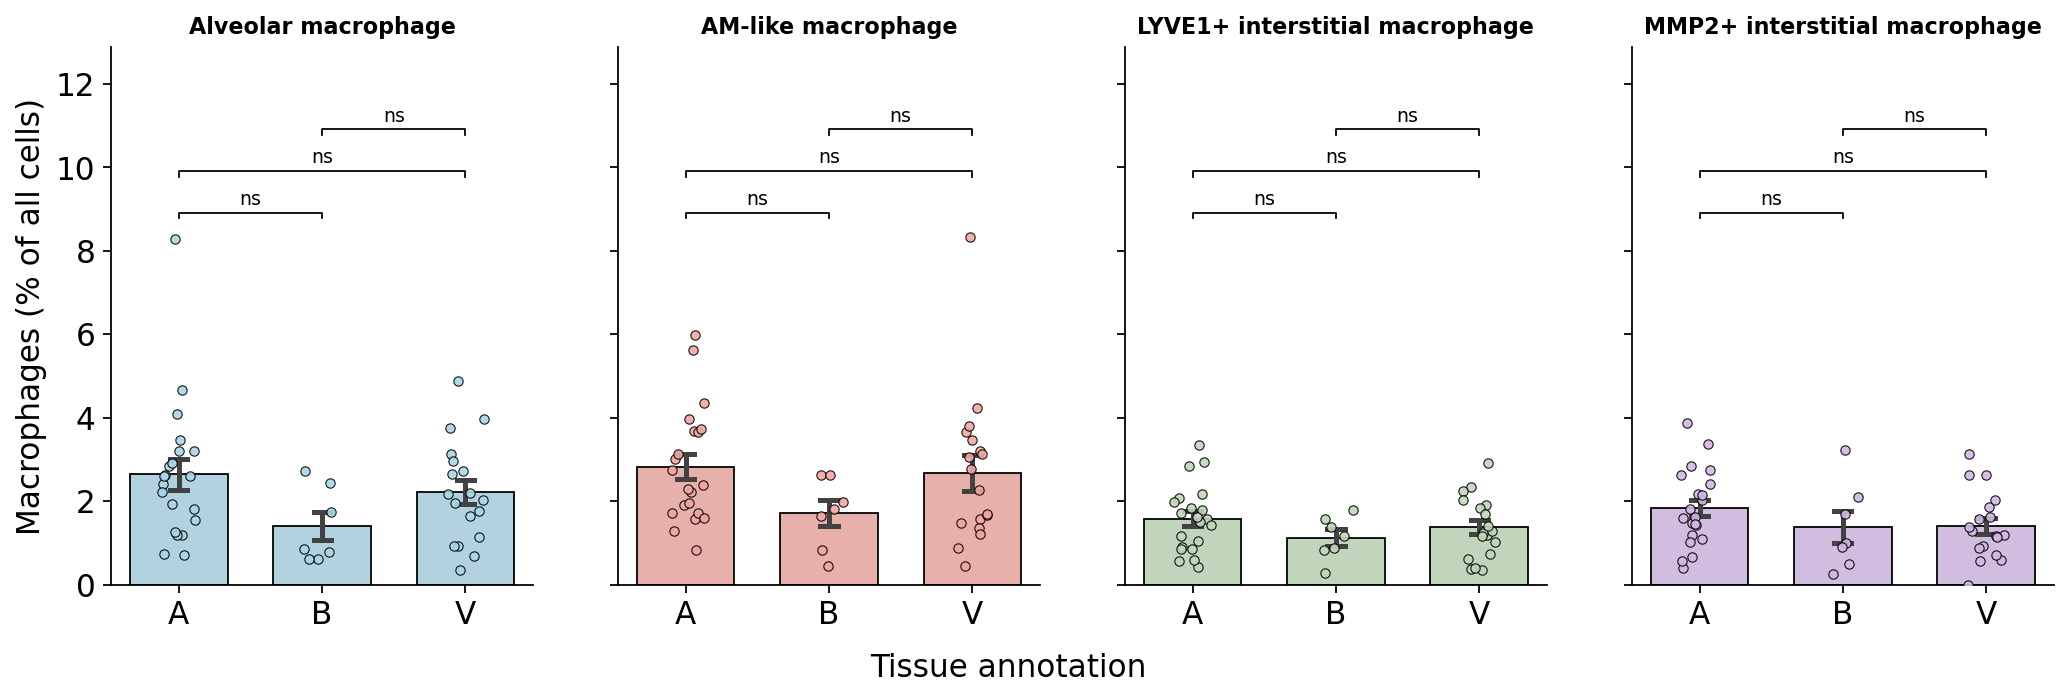

In [35]:
fig, axes, macrophage_abundance_summary, macrophage_abundance_stats = (
    source.plot_macrophage_pct_by_tissue(
        macrophage_abundance_pct_long,
        tissue_order=("A", "B", "V"),
        comparisons=(
            ("A", "B"),
            ("A", "V"),
            ("B", "V"),
        ),
        value_col="percent_of_all_cells",
        ylabel="Macrophages (% of all cells)",
        save="Macrophage_abundance_pct_by_tissue.pdf",
    )
)

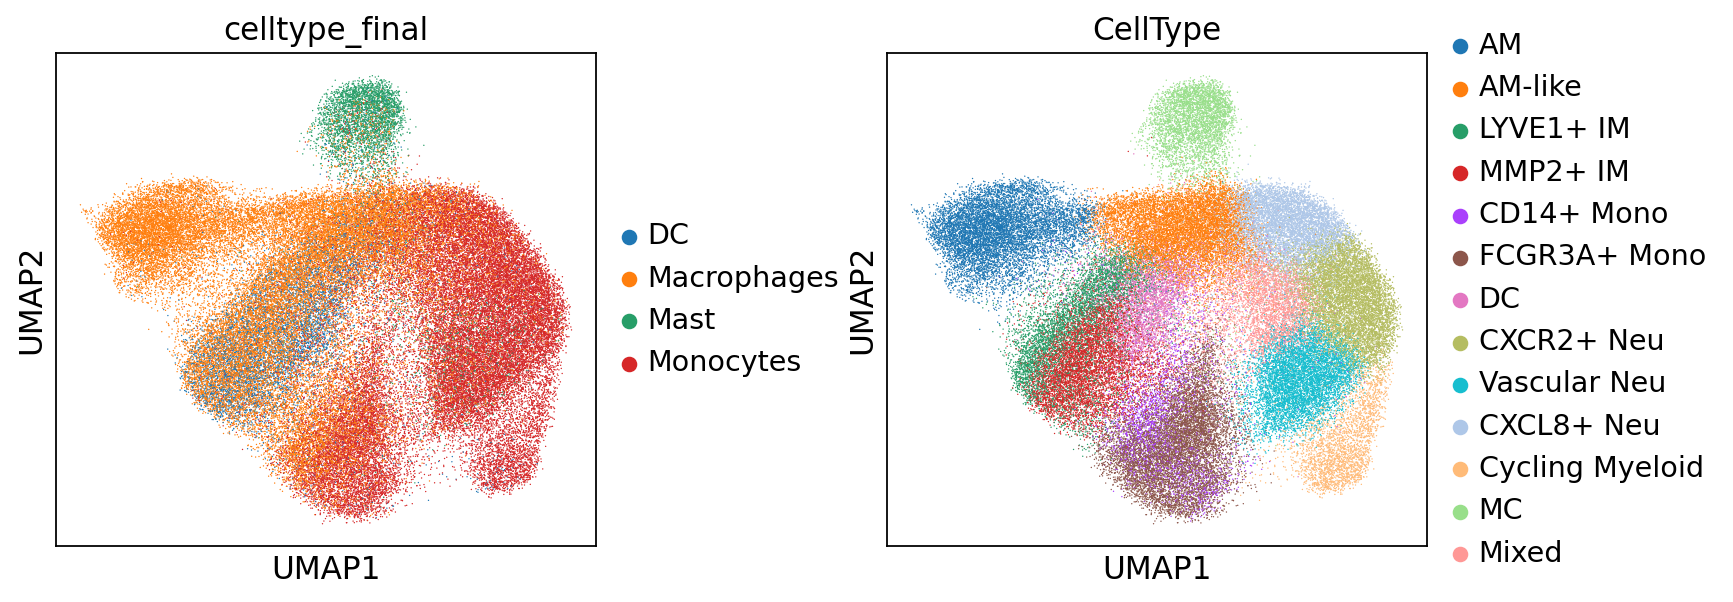

In [36]:
sc.pl.umap(x_myeloid, color=['celltype_final', 'CellType'], wspace=0.4)

In [37]:
x_myeloid.write(outdir + 'myeloid_updated.h5ad')